# T11b — LSTM (Long Short-Term Memory)

Uses `deep_learning.py` for all shared setup, training and evaluation.

**Model:** LSTM — adds a cell state to handle long-range dependencies. Standard go-to for CMAPSS in the literature.

In [1]:
import sys
from pathlib import Path
_root = next(p for p in Path().resolve().parents if (p / "src").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root


In [2]:
from src.models.deep_learning import *
import torch.nn as nn

print(f"Device: {DEVICE}")

Device: mps


In [3]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False   # required for full reproducibility
print(f"Seeds fixed: {SEED}")


Seeds fixed: 42


## 1. Load data & build windows

In [4]:
train_df, test_df = load_data()
FEAT_COLS  = select_features(train_df)
N_FEATURES = len(FEAT_COLS)

X_train, y_train, X_val, y_val = engine_split(train_df, FEAT_COLS)
X_test, y_test = build_windows(test_df, FEAT_COLS, is_test=True)

train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test
)


Train shape : (61249, 123)  (249 engines)
Test  shape : (41214, 123)   (248 engines)
Feature columns (48): ['s2_rmean_5', 's3_rmean_5', 's4_rmean_5', 's6_rmean_5', 's7_rmean_5'] ...
Train engines: 199  Val engines: 50
X_train: (43750, 30, 48)  X_val: (50, 30, 48)
Train batches: 342  Val batches: 1


## 2. Model definition

LSTM — forget gate + input gate + cell state allow it to learn what to remember across long sequences.

In [5]:
from src.models.dl_architectures import LSTMModel

model = LSTMModel(n_features=N_FEATURES, dropout=0.1)

## 3. Train

In [6]:
model, train_losses, val_losses = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    epochs       = EPOCHS,
    model_name   = "LSTM",
)

  [LSTM] Epoch  10 | train=3.2984 | val=5.7732 | best=1.9080  [NASALoss]
  [LSTM] Early stop at epoch 14


## 4. Evaluate

In [7]:
from src.evaluation.metrics import evaluate

y_true, y_pred = predict_test(model, test_loader)
results = evaluate(y_true, y_pred, model_name="LSTM")
print(results)

  [LSTM] RMSE: 32.7409  |  NASA Score: 6138.51 (mean: 24.75)  |  R2: 0.4197  |  Bias: -20.95 (early ↓)
{'rmse': 32.74092102050781, 'nasa_score': 6138.5068359375, 'nasa_score_mean': 24.752043693296372, 'r2_score': 0.419735848903656, 'bias': -20.949607849121094}


In [8]:
from src.evaluation.metrics import save_model_results

save_model_results(
    model_name = "LSTM",
    model_type = "dl",
    y_true     = y_true,
    y_pred     = y_pred,
)

  [LSTM] RMSE: 32.7409  |  NASA Score: 6138.51 (mean: 24.75)  |  R2: 0.4197  |  Bias: -20.95 (early ↓)
  → Saved to results/all_model_results.csv


{'rmse': 32.74092102050781,
 'nasa_score': 6138.5068359375,
 'nasa_score_mean': 24.752043693296372,
 'r2_score': 0.419735848903656,
 'bias': -20.949607849121094}

## 5. Plots

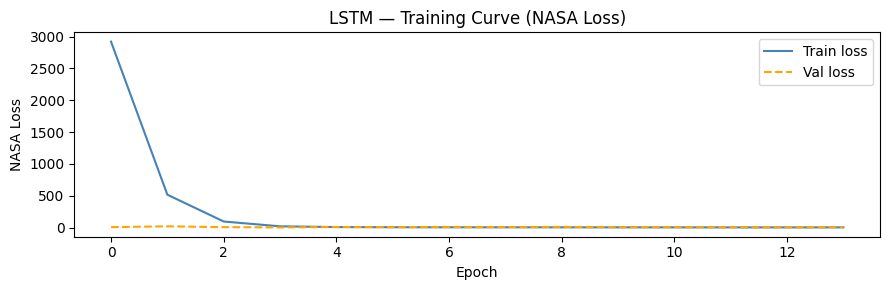

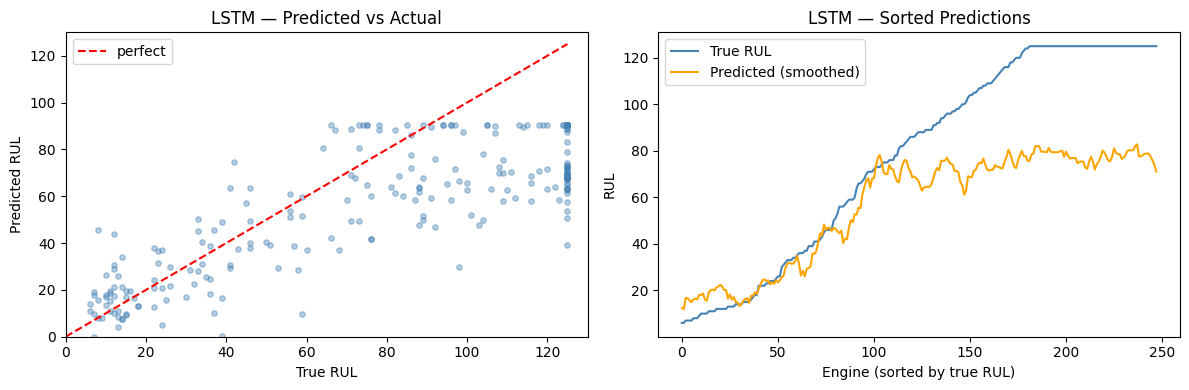

In [9]:
plot_loss_curves(train_losses, val_losses, model_name="LSTM")
plot_predictions(y_true, y_pred, model_name="LSTM")
